# Candidate Test 2022 Analysis Part 2

In this assignment I analyse Candidate Test 2022 data using dimensionality reduction and clustering.

This is an unsupervised learning assignment because the goal is not to predict a target label, but to find structure in the candidates' answers.

Main methods used:
- PCA
- explained variance analysis
- party positions on PC1 and PC2
- k-means clustering
- elbow method
- hierarchical clustering
- dendrogram
- DBSCAN
- distance analysis of elected candidates

The goal is to reduce the high-dimensional answer data into fewer dimensions and then analyse political patterns and clusters.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import seaborn as sns

alldata = pd.read_excel("alldata.xlsx")

# Question columns are the answer features used for PCA and clustering
cols_without_questions = ["navn", "parti", "storkreds", "alder"]
question_cols = [c for c in alldata.columns if c not in cols_without_questions]

# Party labels
y = alldata["parti"]
y = y.dropna()

# Input data contains only the question answers
X = alldata[question_cols]

party_colors = {
    "Alternativet": "#2C903B",
    "Danmarksdemokraterne": "#8CC1FB",
    "Dansk Folkeparti": "#F3C946",
    "Det Konservative Folkeparti": "#9EBA29",
    "Enhedslisten": "#ED8019",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#2C903B",
    "Kristendemokraterne": "#D9D9D9",
    "Liberal Alliance": "#23C3CD",
    "Løsgænger": "#444444",
    "Moderaterne": "#6C38E5",
    "Nye Borgerlige": "#054F5C",
    "Radikale Venstre": "#733581",
    "Socialdemokratiet": "#B32722",
    "Socialistisk Folkeparti": "#DC0778",
    "Venstre": "#006696",
}
#configure the colors to represent the image above.
party_labels = party_colors.keys()

colors = [party_colors.get(p, "#888888") for p in party_labels]



### Why there is no train/test split

I do not use a train/validation/test split in this assignment because this is unsupervised learning.

The goal is not to predict a target variable.  
Instead, I use PCA and clustering to find structure in the candidate answers.

Party labels are used only afterwards for interpretation and visualization.

### PCA

Apply PCA to reduce dimensionality
PCA finds the main axes of variation in the data (political dimensions)

PC1 captures the largest variance in the data.  
PC2 captures the second largest variance and is orthogonal to PC1.

In [2]:
from sklearn.decomposition import PCA

# Apply PCA to the question answer data 
# PCA finds the main directions of variation in the dataset 
pca = PCA()
X_pca = pca.fit_transform(X)

print(f"Original shape: {X.shape}")
print(f"PCA shape: {X_pca.shape}")

# Explained variance shows how much information each principal component captures
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio per PC:", explained_variance)

Original shape: (867, 49)
PCA shape: (867, 49)
Explained variance ratio per PC: [0.45607901 0.11056386 0.05043851 0.0325988  0.02766972 0.02107247
 0.0184712  0.01539926 0.01446637 0.01362734 0.01246812 0.01212725
 0.0113937  0.01054674 0.01004846 0.00959159 0.0093957  0.00883042
 0.0081701  0.00784091 0.00779958 0.00742192 0.00722559 0.00713066
 0.00684986 0.00647814 0.00630544 0.00613937 0.00593062 0.00568824
 0.00543105 0.00517121 0.00510938 0.00492418 0.004825   0.00465238
 0.00445633 0.00440064 0.00393341 0.00388561 0.00373186 0.00349443
 0.0034039  0.00308259 0.00295079 0.00266224 0.00249714 0.00188207
 0.00173684]


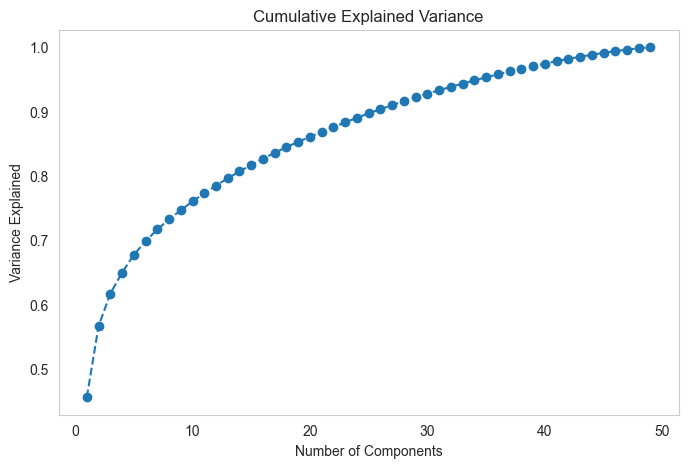

In [3]:
# Calculate cumulative explained variance.
# This shows how much total variance is captured by the first k components.
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid()
plt.show()

In [4]:
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_90}")

Components needed for 90% variance: 26


### Important questions for PC1 and PC2

PCA loadings show how strongly each original question contributes to a principal component.

Questions with large absolute loading values are the most important for that component.

In [5]:
# Create a DataFrame with PCA loadings.
# Loadings show how much each original question contributes to each PC.
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))]
)
pc1_top = loadings["PC1"].abs().sort_values(ascending=False)
pc2_top = loadings["PC2"].abs().sort_values(ascending=False)
top_pc1 = loadings.reindex(pc1_top.index).head(5)
top_pc2 = loadings.reindex(pc2_top.index).head(5)

display("Top PC1 questions:\n", top_pc1)
display("\nTop PC2 questions:\n", top_pc2)

'Top PC1 questions:\n'

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49
531,0.205416,-0.070633,0.034424,0.029472,-0.012094,0.047346,0.219827,-0.039974,0.045868,-0.191414,...,0.150942,-0.199759,0.061745,0.051491,-0.123211,-0.154775,0.078338,0.122970,-0.029659,0.038766
550,0.205066,0.005991,-0.073245,-0.072922,-0.049715,0.178534,-0.024775,0.032639,-0.121543,-0.252342,...,-0.179013,0.124152,-0.171843,-0.244913,0.057590,0.156902,-0.012261,-0.092505,-0.019733,-0.030098
3b,0.204075,0.135642,0.033883,0.081013,0.007262,-0.113744,-0.108776,-0.048256,0.056101,-0.012242,...,-0.185316,0.034019,0.468997,-0.197573,-0.004957,0.170630,-0.360291,0.120037,-0.026530,0.007161
537,-0.198883,0.102179,-0.017608,-0.078153,-0.013152,0.023049,-0.016286,0.179314,0.051697,-0.124878,...,0.116502,-0.228975,-0.058718,0.044295,-0.255255,0.394293,-0.191147,-0.072336,-0.040251,-0.058119
543,-0.193057,-0.002944,-0.141850,-0.009642,-0.078393,0.000088,0.060424,-0.084328,0.062776,-0.129944,...,0.072795,-0.056252,-0.260750,-0.154901,0.021737,-0.153563,-0.066314,-0.003186,-0.038618,0.065063


'\nTop PC2 questions:\n'

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC40,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49
556,-0.133250,0.356049,-0.081586,-0.009276,0.082747,-0.227909,0.208346,-0.086085,0.052713,-0.113791,...,-0.057268,-0.062368,-0.018436,-0.005948,0.017696,0.043266,-0.019605,-0.135905,0.608421,-0.260279
10b,0.128328,-0.355004,0.078435,-0.004371,-0.080396,0.235354,-0.179732,0.055898,-0.052476,0.056470,...,0.040397,-0.043678,-0.033294,-0.008211,-0.010085,-0.002267,-0.001823,-0.068197,0.633112,-0.309135
551,-0.116240,-0.298896,0.067716,0.120752,-0.098375,0.135314,-0.069289,-0.206473,-0.228740,-0.075326,...,-0.213680,-0.024371,0.017669,0.152498,0.031999,0.099651,-0.269800,0.086709,0.059771,-0.030668
553,-0.016978,-0.249885,-0.025809,0.249041,-0.097609,-0.346597,-0.068601,-0.070374,0.336013,0.003408,...,0.031129,0.040520,-0.015713,-0.033694,-0.012807,-0.026131,-0.045486,0.053457,0.022150,-0.033023
555,-0.189554,-0.243982,-0.150314,-0.127666,-0.018116,0.065006,0.189717,-0.056383,-0.107028,0.066929,...,-0.086066,0.173865,-0.018479,-0.009813,-0.031646,-0.020869,0.125327,0.059074,-0.323348,-0.615293


In [6]:
rows = []

for pc in ["PC1", "PC2"]:

    top_features = loadings[pc].abs().sort_values(ascending=False).head(5).index

    for rank, feature in enumerate(top_features, start=1):

        q_num = str(feature).replace("DR", "").replace("TV2", "").replace("_", "")

        rows.append({
            "PC": pc,
            "Rank": rank,
            "Question": q_num,
            "Weight": loadings.loc[feature, pc]
        })

result = pd.DataFrame(rows)

display(result)

,PC,Rank,Question,Weight
0,PC1,1,531,0.205416
1,PC1,2,550,0.205066
2,PC1,3,3b,0.204075
3,PC1,4,537,-0.198883
4,PC1,5,543,-0.193057
5,PC2,1,556,0.356049
6,PC2,2,10b,-0.355004
7,PC2,3,551,-0.298896
8,PC2,4,553,-0.249885
9,PC2,5,555,-0.243982


In [7]:
# Put PC1 and PC2 into a DataFrame
pc_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "party": y
})

# Average PC1 and PC2 per party
party_pc_avg = pc_df.groupby("party").mean()

display(party_pc_avg)

,PC1,PC2
party,,
Alternativet,7.057642,1.697298
Danmarksdemokraterne,-5.639608,-5.430754
Dansk Folkeparti,-4.994730,-4.785465
Det Konservative Folkeparti,-6.479327,1.205848
Enhedslisten,9.631156,-1.262511
"Frie Grønne, Danmarks Nye Venstrefløjsparti",8.906763,0.843119
Kristendemokraterne,0.231551,3.773637
Liberal Alliance,-7.629389,3.902370
Løsgænger,-1.842855,0.392431


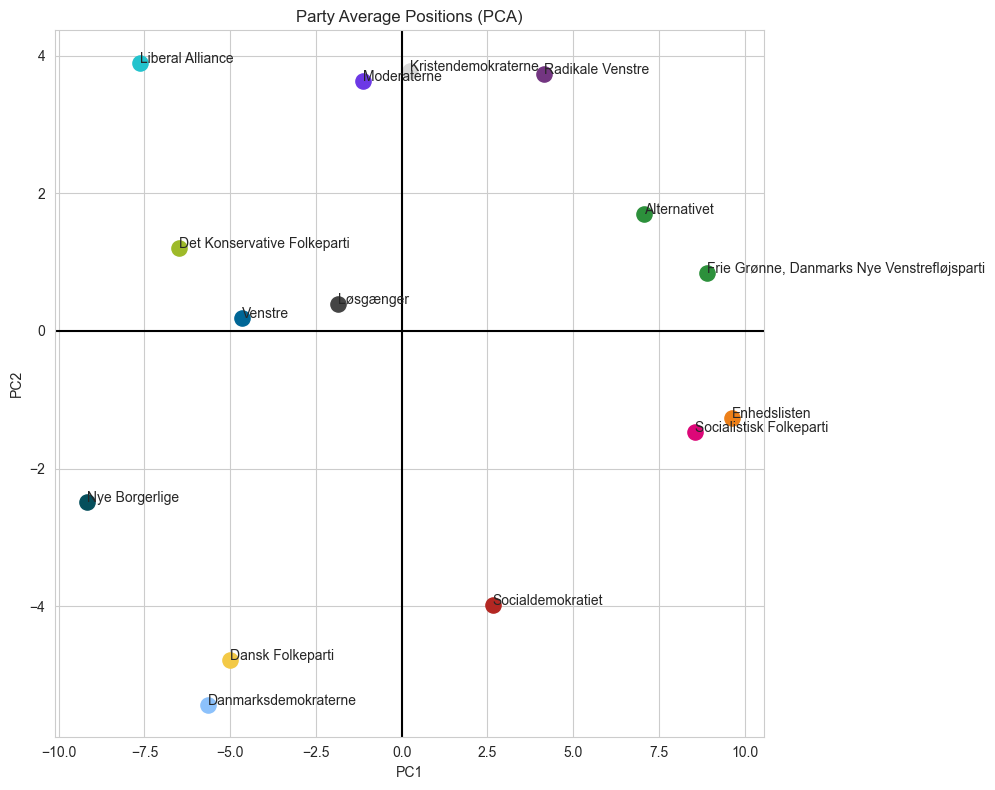

In [8]:
# Calculate average PC1 and PC2 position for each party.
party_mean = pc_df.groupby("party").mean()

# Plot
plt.figure(figsize=(10, 8))

for party in party_mean.index:
    x = party_mean.loc[party, "PC1"]
    y = party_mean.loc[party, "PC2"]

    plt.scatter(
        x, y,
        color=party_colors.get(party, "black"),
        s=120
    )

    plt.text(x, y, party)

# Axes
plt.axhline(0, color="black")
plt.axvline(0, color="black")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Party Average Positions (PCA)")

plt.grid(True)
plt.tight_layout()
plt.show()

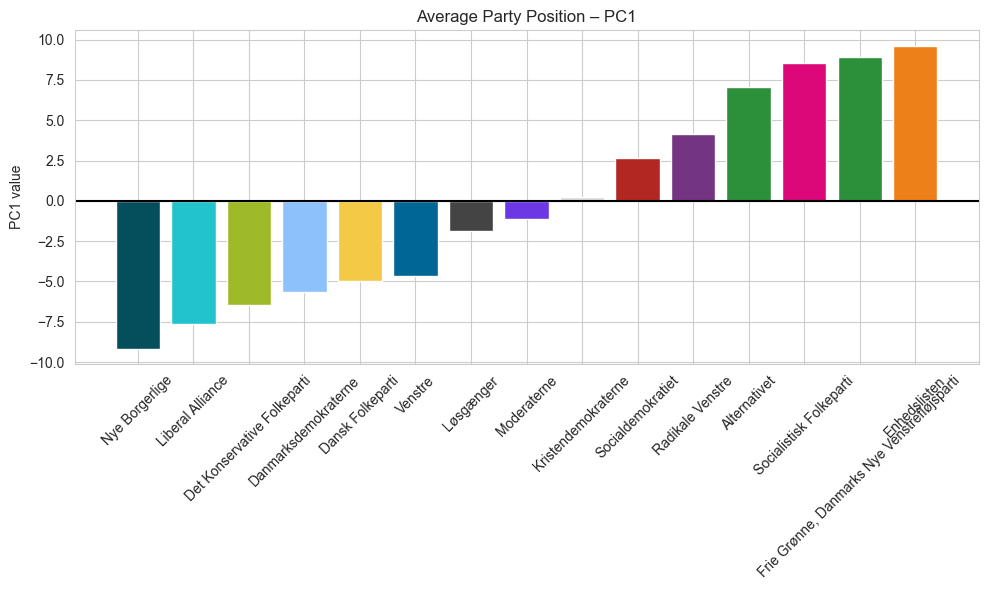

In [9]:
pc1_data = party_mean["PC1"].sort_values()

plt.figure(figsize=(10, 6))

plt.bar(
    pc1_data.index,
    pc1_data.values,
    color=[party_colors.get(p, "black") for p in pc1_data.index]
)

plt.axhline(0, color="black")
plt.xticks(rotation=45)
plt.title("Average Party Position – PC1")
plt.ylabel("PC1 value")

plt.tight_layout()
plt.show()

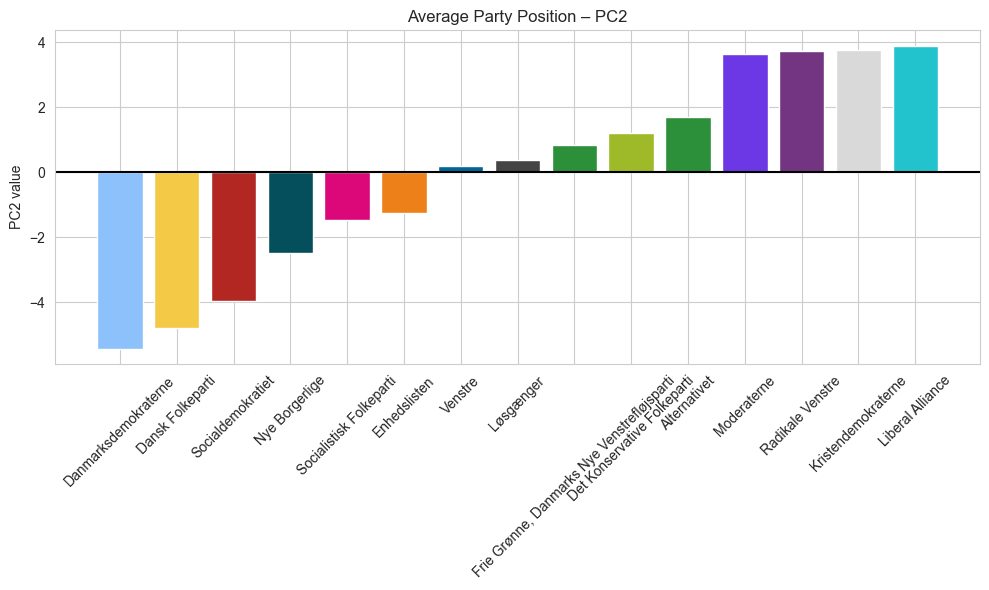

In [10]:
pc2_data = party_mean["PC2"].sort_values()

plt.figure(figsize=(10, 6))

plt.bar(
    pc2_data.index,
    pc2_data.values,
    color=[party_colors.get(p, "black") for p in pc2_data.index]
)

plt.axhline(0, color="black")
plt.xticks(rotation=45)
plt.title("Average Party Position – PC2")
plt.ylabel("PC2 value")

plt.tight_layout()
plt.show()

### k-means clustering

K-means groups candidates into k clusters based on similarity.

The algorithm starts with k centroids, assigns each point to the nearest centroid, recalculates centroids and repeats until stable.

I use 26 PCA components because they preserve around 90% of the variance.  
For plotting, I show the clusters projected onto PC1 and PC2.

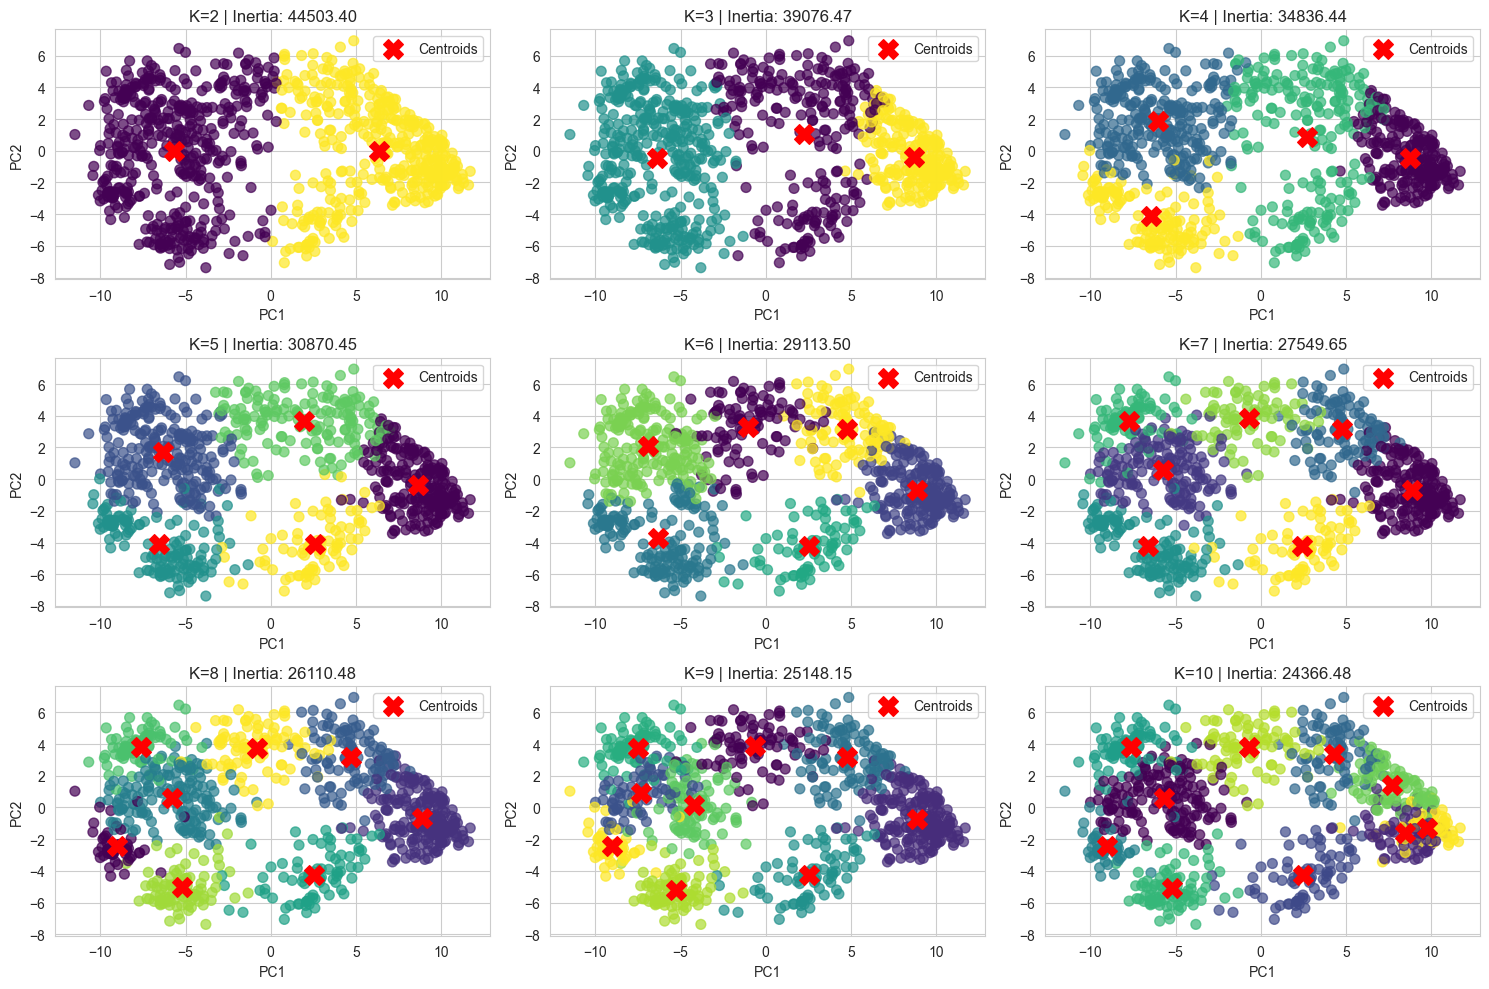

In [11]:
#K-means clustering
# Below is visualisation of different number of cluster would look like (from 2 to 10)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

pca_26 = PCA(n_components=26)
X_pca_26 = pca_26.fit_transform(X)

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]
inertias = []

plt.figure(figsize=(15, 10))

for i, k in enumerate(k_values):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )

    kmeans.fit(X_pca_26)
    inertias.append(kmeans.inertia_)

    plt.subplot(3, 3, i + 1)

    plt.scatter(
        X_pca_26[:, 0],
        X_pca_26[:, 1],
        c=kmeans.labels_,
        cmap="viridis",
        s=50,
        alpha=0.7
    )

    plt.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        marker="X",
        s=200,
        c="red",
        label="Centroids"
    )

    plt.title(f"K={k} | Inertia: {kmeans.inertia_:.2f}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()

plt.tight_layout()
plt.show()

### Elbow method

The elbow method helps choose the number of clusters k.

It plots inertia for different k values.  
Inertia measures how close points are to their assigned cluster centroids.

A good k is often near the point where inertia stops decreasing strongly.

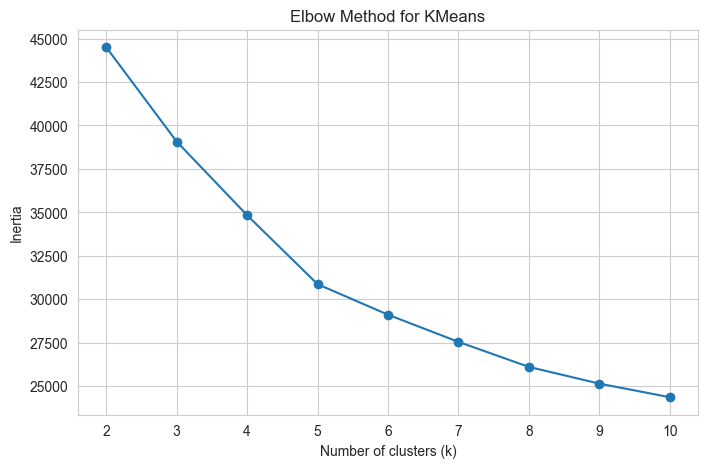

In [12]:
#Elobw Method

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.grid(True)
plt.show()

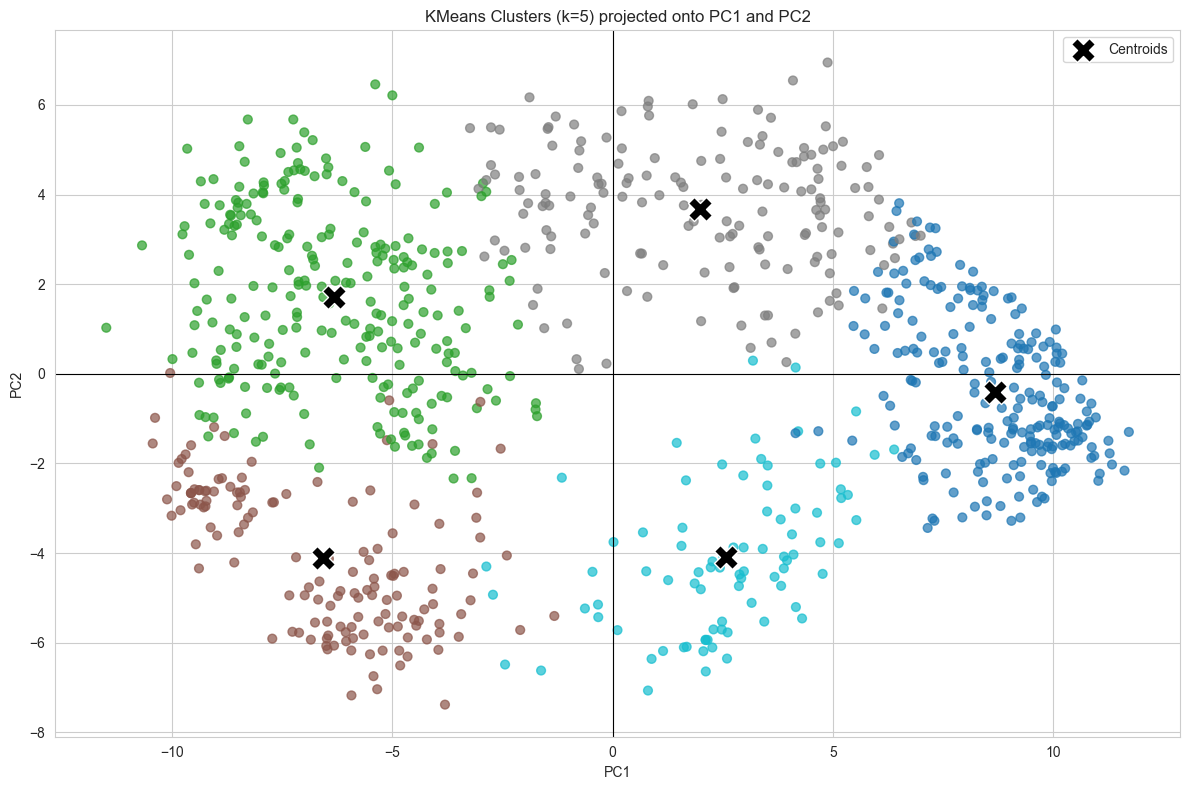

In [13]:
#K means with 5 clusters

km = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42
)

km.fit(X_pca_26)

centroids_pca = km.cluster_centers_

plt.figure(figsize=(12, 8))

plt.scatter(
    X_pca_26[:, 0],
    X_pca_26[:, 1],
    c=km.labels_,
    cmap="tab10",
    alpha=0.7,
    s=40
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=300,
    c="black",
    marker="X",
    edgecolors="white",
    label="Centroids"
)

plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters (k=5) projected onto PC1 and PC2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The k-means plot shows candidate groups projected onto PC1 and PC2.

Because clustering is unsupervised, the clusters do not have one correct answer.  
They need to be interpreted using party labels and political context.

### Hierarchical clustering

Hierarchical clustering builds clusters step by step.

I use agglomerative clustering, which starts with each candidate as its own cluster and then merges the closest clusters.

The dendrogram shows how clusters are merged and at what distance.

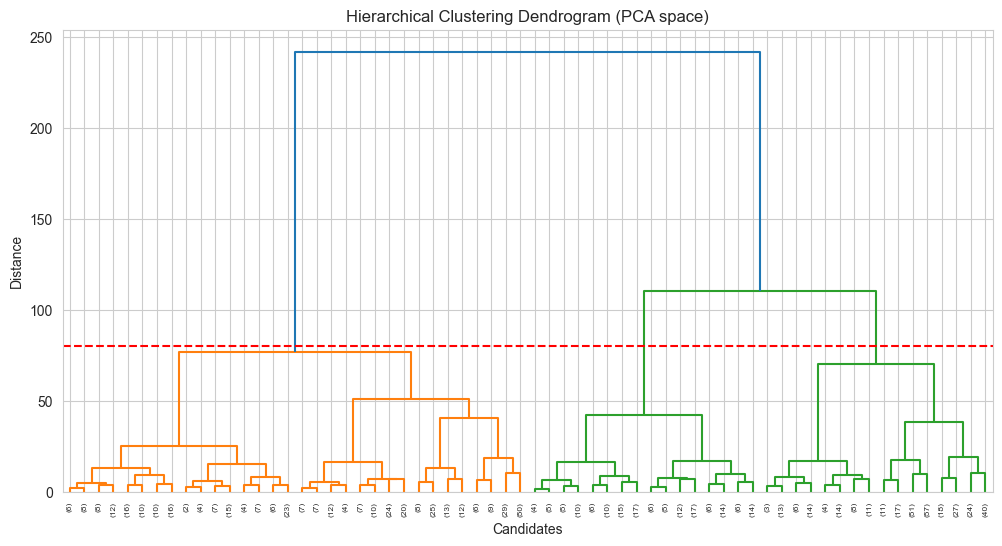

In [14]:
#Hierarchical clustering
#Dendrogram
X_hc = X_pca_26[:, :2]  # use PC1 and PC2

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Ward linkage
Z = linkage(X_hc, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # cleaner visualization
plt.title("Hierarchical Clustering Dendrogram (PCA space)")
plt.xlabel("Candidates")
plt.ylabel("Distance")

# cut line
plt.axhline(80, color='red', linestyle='--')

plt.show()

### Linkage methods

Linkage defines how the distance between clusters is calculated.

I compare single, complete, average and Ward linkage to see how the cluster shapes change.

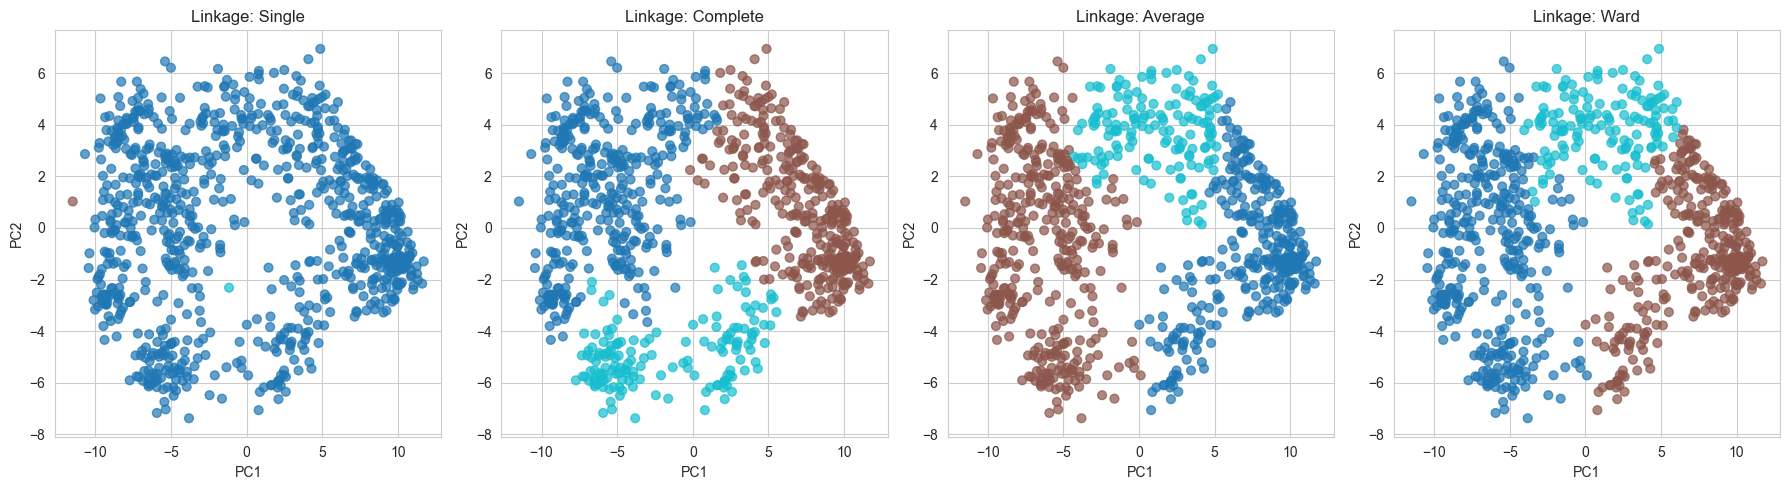

In [15]:
#How different linkage  would look like
X_hc = X_pca_26[:, :2]  # PC1 and PC2

from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

methods = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(18, 5))

for i, link in enumerate(methods):
    model = AgglomerativeClustering(
        n_clusters=3,
        linkage=link
    )

    labels = model.fit_predict(X_hc)

    plt.subplot(1, 4, i + 1)
    plt.scatter(
        X_hc[:, 0],
        X_hc[:, 1],
        c=labels,
        cmap='tab10',
        s=40,
        alpha=0.7
    )

    plt.title(f"Linkage: {link.capitalize()}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)

plt.tight_layout()
plt.show()

### DBSCAN

DBSCAN is a density-based clustering algorithm.

It groups dense regions together and marks sparse points as noise.

Important hyperparameters:
- `eps`: radius around a point
- `min_samples`: minimum number of points needed to form a dense region

DBSCAN does not require choosing the number of clusters beforehand

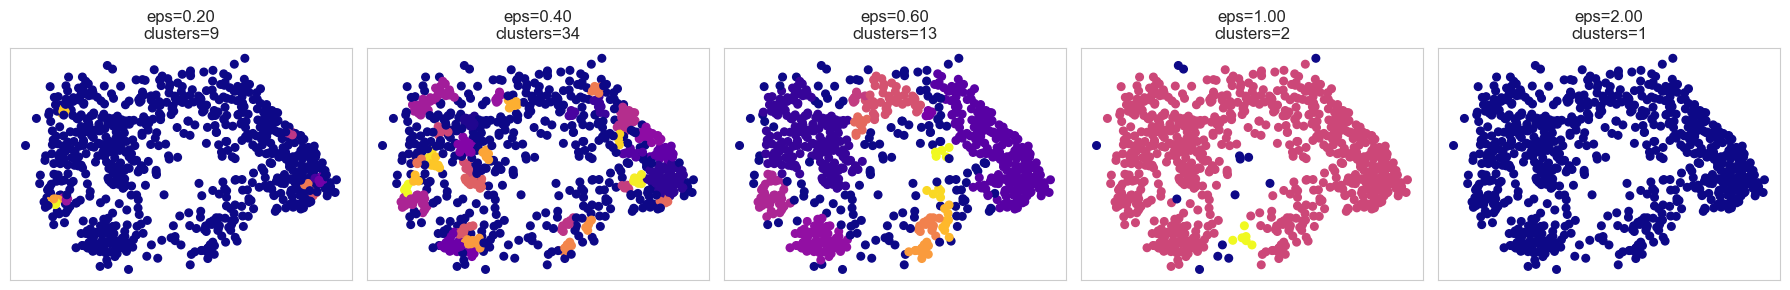

In [16]:
#DBSCAN
from sklearn.cluster import DBSCAN

# Test different eps values to see how DBSCAN changes
e_list = [0.2, 0.4, 0.6, 1.0, 2.0]

# Use higher dimensions for clustering
X_db = X_pca_26[:, :2]

plt.figure(figsize=(18, 3))

for i, e in enumerate(e_list):
    res = DBSCAN(eps=e, min_samples=5).fit_predict(X_db)

    n_clusters = len(set(res)) - (1 if -1 in res else 0)

    plt.subplot(1, len(e_list), i+1)

    # Plot only first 2 PCA dims
    plt.scatter(
        X_pca_26[:, 0],
        X_pca_26[:, 1],
        c=res,
        cmap='plasma',
        s=30
    )

    plt.title(f"eps={e:.2f}\nclusters={n_clusters}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

Clusters: 5
Noise: 116


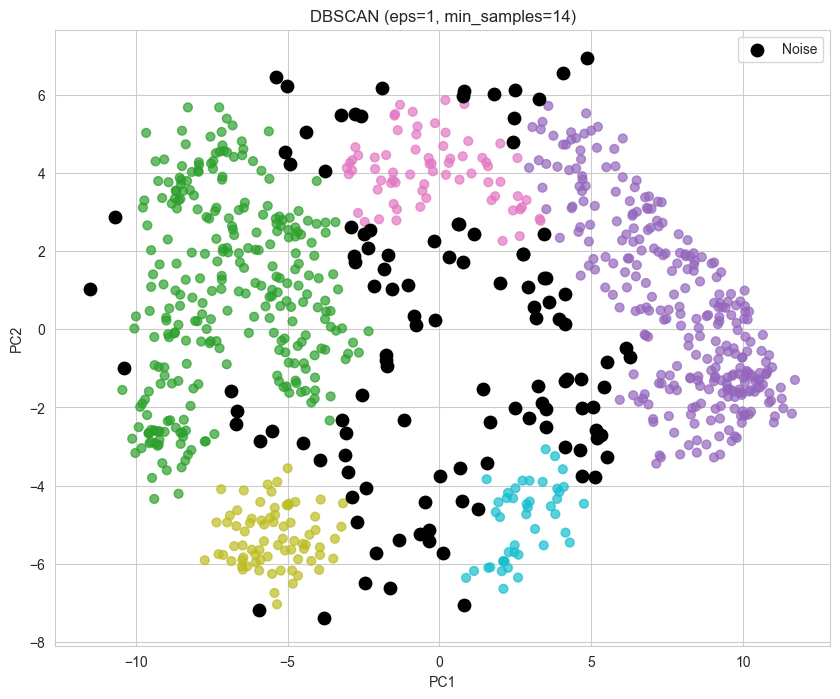

In [17]:
# DBSCAN
# Final DBSCAN model with selected eps and min_samples.
db = DBSCAN(
    eps=1,
    min_samples=14
)

labels = db.fit_predict(X_db)

# Stats
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Clusters:", n_clusters)
print("Noise:", n_noise)

# Plot clusters
plt.figure(figsize=(10, 8))

plt.scatter(
    X_db[:, 0],
    X_db[:, 1],
    c=labels,
    cmap="tab10",
    s=40,
    alpha=0.7
)

# Highlight noise
plt.scatter(
    X_db[labels == -1, 0],
    X_db[labels == -1, 1],
    c="black",
    s=80,
    label="Noise"
)

plt.title(f"DBSCAN (eps={1}, min_samples=14)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

The DBSCAN result shows the number of clusters and noise points.

Noise points are candidates that do not belong to a dense region.

### Elected candidates and political distance

In this part I analyse elected candidates in PCA space.

I use distances between candidates to find who are most similar and most different based on their answers.

In [18]:
# An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.

from sklearn.metrics import pairwise_distances

# Load elected candidates
elected = pd.read_excel("electeddata.xlsx")

# Same question columns as before
X_elected = elected[question_cols]
y_elected = elected["parti"]

# Transform elected candidates using the PCA model already fitted on X
X_elected_pca = pca.transform(X_elected)

elected_pc_df = pd.DataFrame({
    "PC1": X_elected_pca[:, 0],
    "PC2": X_elected_pca[:, 1],
    "navn": elected["navn"],
    "parti": elected["parti"]
})

elected_pc_df.head()

,PC1,PC2,navn,parti
0,9.273625,-1.964813,Karsten Hønge,Socialistisk Folkeparti
1,9.696126,-0.486754,Torsten Gejl,Alternativet
2,10.149315,-1.104211,Mai Villadsen,Enhedslisten
3,-4.844721,-6.174884,Hans Kristian Skibby,Danmarksdemokraterne
4,-4.498955,-2.915193,Troels Lund Poulsen,Venstre


In [19]:
# Use PCA space to calculate distances between elected candidates.
dist_matrix = pairwise_distances(elected_pc_df[["PC1", "PC2"]])

dist_df = pd.DataFrame(
    dist_matrix,
    index=elected_pc_df["navn"],
    columns=elected_pc_df["navn"]
)

# Most different candidates
# Candidates who disagree the most (largest distance)
most_different = dist_df.stack().sort_values(ascending=False)

# remove duplicate pairs
most_different = most_different[
    most_different.index.get_level_values(0) != most_different.index.get_level_values(1)
]

most_different.head(10)

navn                      navn                    
Sandra Elisabeth Skalvig  Peder Hvelplund             21.597218
Peder Hvelplund           Sandra Elisabeth Skalvig    21.597218
                          Steffen Larsen              21.498938
Steffen Larsen            Peder Hvelplund             21.498938
Ole Birk Olesen           Peder Hvelplund             20.942086
Peder Hvelplund           Ole Birk Olesen             20.942086
Steffen Frølund           Peder Hvelplund             20.929012
Peder Hvelplund           Steffen Frølund             20.929012
Rosa Lund                 Sandra Elisabeth Skalvig    20.888662
Sandra Elisabeth Skalvig  Rosa Lund                   20.888662
dtype: float64

In [20]:
# Candidates who agree the most (smallest distance)
most_similar = dist_df.replace(0, np.nan).stack().sort_values()
most_similar.head(10)

navn                       navn                     
Lea Wermelin               Rasmus Stoklund              0.047733
Rasmus Stoklund            Lea Wermelin                 0.047733
Hans Andersen              Peter Juel-Jensen            0.066687
Peter Juel-Jensen          Hans Andersen                0.066687
Lise Bech                  Betina Kastbjerg             0.074679
Betina Kastbjerg           Lise Bech                    0.074679
Brigitte Klintskov Jerkel  Søren Pape Poulsen           0.082254
Søren Pape Poulsen         Brigitte Klintskov Jerkel    0.082254
Magnus Johannes Heunicke   Jesper Petersen              0.092288
Jesper Petersen            Magnus Johannes Heunicke     0.092288
dtype: float64

In [21]:
# Measure internal disagreement within each party
# Standard deviation = how spread out party members are

party_spread = elected_pc_df.groupby("parti")[["PC1", "PC2"]].std()

party_spread["total_spread"] = party_spread["PC1"] + party_spread["PC2"]

party_spread.sort_values("total_spread", ascending=False)

,PC1,PC2,total_spread
parti,,,
Socialdemokratiet,2.245090,1.513288,3.758378
Moderaterne,2.419579,1.175335,3.594915
Det Konservative Folkeparti,1.831742,1.404262,3.236004
Alternativet,1.322638,1.510430,2.833068
Venstre,1.114785,1.705216,2.820001
Liberal Alliance,1.240936,1.303146,2.544082
Socialistisk Folkeparti,1.140387,1.162047,2.302434
Danmarksdemokraterne,1.124531,0.852527,1.977058
Dansk Folkeparti,0.996840,0.897235,1.894074


## Final conclusion

This assignment focused on unsupervised learning using Candidate Test 2022 data.

I used PCA to reduce the dimensionality of the candidate answer data and visualize the main political structure.  
PC1 captures the largest variance, and PC2 captures the second largest variance.

I checked explained variance to see how many components were needed to preserve most of the information.  
The 2D PCA plot is useful for visualization, but it is only a simplified view of the full dataset.

Then I applied clustering methods:
- k-means
- hierarchical clustering
- DBSCAN

K-means requires choosing the number of clusters k.  
Hierarchical clustering shows how clusters merge using a dendrogram.  
DBSCAN finds dense regions and can mark some candidates as noise.

Finally, I analysed elected candidates using distances in PCA space to find which candidates were most similar, most different and which parties had more internal spread.

A limitation is that unsupervised learning has no single correct answer.  
The results depend on the algorithm, parameters and interpretation.